### Домашка

1) По аналогии с функцией best_continious_split, напишите функцию best_categorical_split (которая перебирает все возможные комбинации категорий для сплита), если количество категорий больше 5, то использует стратегию one vs rest

P.S Возможно best_continious_split придётся переписать, убрав предположение о том, что все значения в фиче разные

2) Реализовать собственный класс дерева решения для бинарной классификации

3) Протестировать его на датасете одобрения кредита (approval rate)

4) Сравнить качество работы модели при разных критериях разбиения (gini vs entropy)

5) Сравнить качество с sklearn деревом

In [105]:
import pandas as pd
import numpy as np
from itertools import chain, combinations
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score, \
                            ConfusionMatrixDisplay, \
                            accuracy_score, \
                            precision_score, \
                            recall_score, \
                            f1_score

In [106]:
def show_metrics(true, preds, probas=None):

    print(f"Accuracy: {accuracy_score(true, preds):.2}")
    print(f"Precision: {precision_score(true, preds):.2}")
    print(f"Recall: {recall_score(true, preds):.2}")
    print(f"F1 score: {f1_score(true, preds):.2}")
    print(f"ROC AUC score (predict): {roc_auc_score(true, preds):.2}")

    if probas is not None:
        print(f"ROC AUC score (predict_proba): {roc_auc_score(true, probas):.2}")

    ConfusionMatrixDisplay.from_predictions(true, preds)

## best categorical and continios split

In [107]:
def best_continios_split(values, targets, criterion, plot=False):
    sorted_pairs = sorted(list(zip(values, targets)), key = lambda x: x[0])

    n = len(sorted_pairs)
    p = sum(targets) / n
    node_criterion = criterion(p)

    best_criterion = node_criterion
    best_split = None

    split_vals = []
    criterion_vals = []

    ones = 0
    total_ones = sum(targets)

    for i in range(1, len(sorted_pairs)):
        split_val = (sorted_pairs[i-1][0] + sorted_pairs[i][0]) / 2
        ones += sorted_pairs[i-1][1]

        p_left = ones / i
        p_right = (total_ones - ones) / (n-i)

        split_criterion = i / n * criterion(p_left) + (n-i) / n * criterion(p_right)

        split_vals.append(split_val)
        criterion_vals.append(split_criterion)

        if split_criterion < best_criterion:
            best_criterion = split_criterion
            best_split = split_val

    if plot:
        plt.plot(split_vals, criterion_vals)

    return (best_split, best_criterion)

In [108]:
def best_categorical_split(values, targets, criterion, plot=False):
    """
    Находит наилучшее разбиение категориального признака по заданному критерию (например, Gini, entropy).
    Если уникальных категорий <=5, перебирает все возможные варианты разбиения (кроме пустого и полного множества).
    Если категорий больше 5 — перебирает только варианты one-vs-rest.

    Аргументы:
        values:  список/массив значений категориального признака
        targets: список/массив целевой переменной (0/1)
        criterion: функция критерия (например, gini или entropy)
        plot:  если True — рисует график значений критерия для всех разбиений

    Возвращает:
        best_split: кортеж категорий (левая часть разбиения)
        best_criterion: наименьшее значение критерия при лучшем разбиении
    """

    categories = list(set(values))
    n = len(values)
    total_ones = sum(targets)
    node_p = total_ones / n
    node_criterion = criterion(node_p)

    best_criterion = node_criterion
    best_split = None

    split_vals = []
    criterion_vals = []

    def all_subsets(ss):
        return chain.from_iterable(combinations(ss, r) for r in range(1, len(ss)))

    # Определяем, как будем перебирать сплиты
    if len(categories) <= 5:
        candidate_splits = list(all_subsets(categories))
    else:
        candidate_splits = [(cat,) for cat in categories]  # one-vs-rest

    for subset in candidate_splits:
        left_mask = [v in subset for v in values]

        left_size = sum(left_mask)
        right_size = n - left_size

        if left_size == 0 or right_size == 0:
            continue

        left_ones = sum(t for t, m in zip(targets, left_mask) if m)
        right_ones = total_ones - left_ones

        p_left = left_ones / left_size if left_size > 0 else 0
        p_right = right_ones / right_size if right_size > 0 else 0

        split_criterion = left_size / n * criterion(p_left) + right_size / n * criterion(p_right)

        split_vals.append(subset)
        criterion_vals.append(split_criterion)

        if split_criterion < best_criterion:
            best_criterion = split_criterion
            best_split = subset

    if plot:
        plt.bar(range(len(criterion_vals)), criterion_vals)
        plt.xlabel("Split number")
        plt.ylabel("Criterion")
        plt.title("Criterion by Split (Categorical)")

    return best_split, best_criterion


## MyDecisionTreeClassifier

In [109]:
# Используя функции нахождения сплита, реализуйте свой класс MyDecisionTreeClassifier
# Для бинарной классификации, который может использовать в качестве критерия
# gini impurity и entropy на выбор

class MyDecisionTreeClassifier:
    def __init__(self, criterion='gini', max_leaves=None, min_samples_leaf=1):
        '''
        Конструктор класса
        criterion -- критерий может быть либо 'gini', либо 'entropy'
        max_leaves -- максимальное количество листо в дереве, если None -- то дерево не ограничено
        min_samples_leaf -- минимальное количество объектов в листе
        '''
        self.criterion = criterion
        self.max_leaves = max_leaves
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        # self.root = {
        #     'feature_name': None,
        #     'threshold ': None,
        #     'left_child': None,
        #     'right_child': None,
        #     'answer': None
        # } # корневой узел

    @staticmethod
    def entropy(p):
        try:
            return -p * np.log2(p) - (1-p) * np.log2(1-p)
        except:
            return 1

    @staticmethod
    def gini_impurity(p):
        return 1 - (p**2 + (1-p)**2)

    def fit(self, X_train, y_train):
        '''
        Функция обучения -- рекурсивно проводит разбиения и выбирает наилучшее
        '''
        if self.criterion == 'gini':
            crit = MyDecisionTreeClassifier.gini_impurity
        elif self.criterion == 'entropy':
            crit = MyDecisionTreeClassifier.entropy

        # Рекурсивная функция для построения дерева
        def build_tree(X, y, leaves_counter):
            # Останавливаемся, если:
            # - все таргеты одинаковы
            # - слишком мало объектов
            # - достигли max_leaves
            num_samples = len(X)
            num_pos = np.sum(y)
            num_neg = num_samples - num_pos
            curr_pred = int(num_pos >= num_neg)

            # Стоп условия
            if num_samples <= self.min_samples_leaf or np.unique(y).size == 1 or \
                    (self.max_leaves is not None and leaves_counter[0] >= self.max_leaves):
                return {'is_leaf': True, 'answer': curr_pred,
                        'proba': num_pos / num_samples, 'size': num_samples}

            best_feat = None  # Лучший признак
            best_thresh = None  # Лучший порог
            best_split = None
            best_criterion = float('inf')
            best_type = None

            # Перебираем все признаки
            for feature in X.columns:
                vals = X[feature].values
                if np.issubdtype(vals.dtype, np.number):
                    tresh, crit_val = best_continios_split(vals, y, crit)
                    split_type = 'num'
                else:
                    tresh, crit_val = best_categorical_split(vals, y, crit)
                    split_type = 'cat'
                if tresh is not None and crit_val < best_criterion:
                    best_criterion = crit_val
                    best_feat = feature
                    best_thresh = tresh
                    best_split = vals
                    best_type = split_type

            if best_feat is None:
                return {'is_leaf': True, 'answer': curr_pred,
                        'proba': num_pos / num_samples, 'size': num_samples}

            # Если нашли лучший признак, то разбиваем
            vals = X[best_feat].values
            if best_type == 'num':
                left_mask = vals < best_thresh
            else:
                left_mask = np.isin(vals, best_thresh)
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                leaves_counter[0] += 1
                return {'is_leaf': True, 'answer': curr_pred,
                        'proba': num_pos / num_samples, 'size': num_samples}
            node = {
                'is_leaf': False,
                'feature_name': best_feat,
                'threshold': best_thresh,
                'split_type': best_type,
                'left_child': build_tree(X[left_mask], y[left_mask], leaves_counter),
                'right_child': build_tree(X[right_mask], y[right_mask], leaves_counter),
            }

            return node

        # счетчик листьев через список чтобы передавать по ссылке (обход рекурсии)
        self.root = build_tree(X_train, np.array(y_train), [0])

    def _predict_one(self, row, node):
        while not node['is_leaf']:
            val = row[node['feature_name']]
            if node['split_type'] == 'num':
                if val < node['threshold']:
                    node = node['left_child']
                else:
                    node = node['right_child']
            else:
                if val in node['threshold']:
                    node = node['left_child']
                else:
                    node = node['right_child']
        return node['answer']

    def predict(self, X):
        '''
        Функция предсказания класса, для каждого наблюдения проходит по дереву, пока не попадёт в лист
        В зависимости от листа, в который попало наблюдение делается предсказание (наиболее часто встречающийся класс)
        '''
        return [self._predict_one(row, self.root) for _, row in X.iterrows()]

    def _predict_proba_one(self, row, node):
        while not node['is_leaf']:
            val = row[node['feature_name']]
            if node['split_type'] == 'num':
                if val < node['threshold']:
                    node = node['left_child']
                else:
                    node = node['right_child']
            else:
                if val in node['threshold']:
                    node = node['left_child']
                else:
                    node = node['right_child']
        return node['proba']

    def predict_proba(self, X):
        '''
        Функция предсказания вероятности класса, для каждого наблюдения проходит по дереву, пока не попадёт в лист
        В зависимости от листа, в который попало наблюдение делается предсказание для каждого класса:
        Его доля в листе
        '''
        return [self._predict_proba_one(row, self.root) for _, row in X.iterrows()]

# P.S. При ограничении на количество листьев, возможно нужно подумать над стратегией отбора листьев. Наивный вариант рекурсивно идти в порядке обхода дерева возможно не самый оптимальный

## Dataset

In [110]:
#Считываем скачанный csv файл
df = pd.read_csv('loan_data.csv')

In [111]:
df.head(2)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0


In [112]:
# Заведём константу, чтобы каждый раз не вспоминать как называется колонка с таргетом
TARGET = 'loan_status'

In [113]:
train, test = train_test_split(df, test_size = 0.3, random_state=42)

In [114]:
def find_best_split(df, feature_col, target_col=TARGET):
    # print('Entropy:')
    # display(best_categorical_split(df[feature_col], df[target_col], MyDecisionTreeClassifier.entropy, plot=True))
    # plt.show()
    
    print('Gini Impurity:')
    display(best_categorical_split(df[feature_col], df[target_col], MyDecisionTreeClassifier.gini_impurity, plot=True))
    plt.show()

Gini Impurity:


(('Master', 'Doctorate'), 0.3454208695114436)

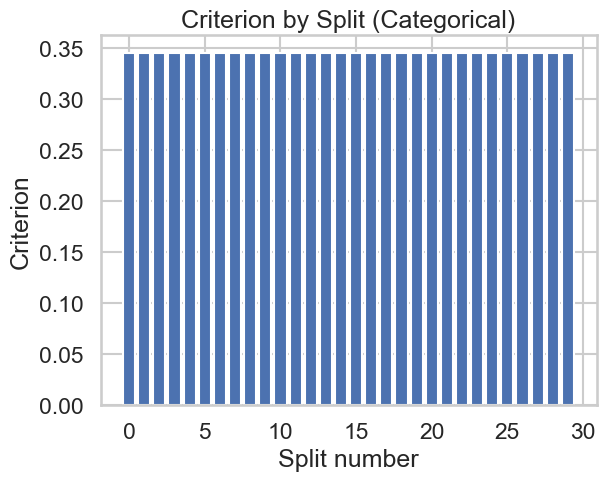

In [115]:
find_best_split(train, 'person_education', TARGET)

## Тест MyDecisonTree на gini

In [116]:
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

In [117]:
tree = MyDecisionTreeClassifier(criterion='gini', max_leaves=10, min_samples_leaf=20)
tree.fit(X_train, y_train)

In [118]:
train_preds = tree.predict(X_train)
test_preds = tree.predict(X_test)

In [119]:
train_probas = tree.predict_proba(X_train)
test_probas = tree.predict_proba(X_test)

Accuracy: 0.91
Precision: 0.8
Recall: 0.77
F1 score: 0.78
ROC AUC score (predict): 0.86
ROC AUC score (predict_proba): 0.95


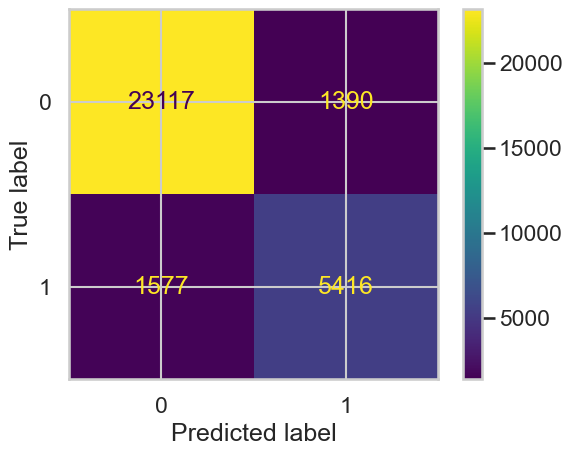

In [120]:
show_metrics(y_train, train_preds, train_probas)

Accuracy: 0.9
Precision: 0.78
Recall: 0.77
F1 score: 0.77
ROC AUC score (predict): 0.85
ROC AUC score (predict_proba): 0.95


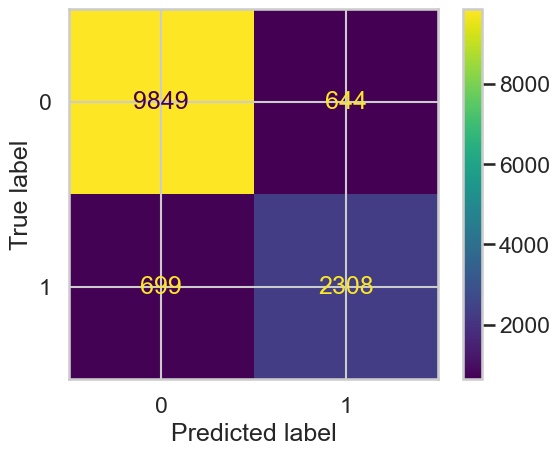

In [121]:
show_metrics(y_test, test_preds, test_probas)

## Тест MyDecisonTree на entropy

In [122]:
tree = MyDecisionTreeClassifier(criterion='entropy', max_leaves=10, min_samples_leaf=20)
tree.fit(X_train, y_train)

/var/folders/_p/8krn6b1j21bbrx339d1x74z80000gn/T/ipykernel_34228/1084392467.py:28: RuntimeWarning: divide by zero encountered in log2
  return -p * np.log2(p) - (1-p) * np.log2(1-p)
/var/folders/_p/8krn6b1j21bbrx339d1x74z80000gn/T/ipykernel_34228/1084392467.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  return -p * np.log2(p) - (1-p) * np.log2(1-p)


In [123]:
train_preds = tree.predict(X_train)
test_preds = tree.predict(X_test)

In [124]:
train_probas = tree.predict_proba(X_train)
test_probas = tree.predict_proba(X_test)

Accuracy: 0.84
Precision: 0.71
Recall: 0.47
F1 score: 0.57
ROC AUC score (predict): 0.71
ROC AUC score (predict_proba): 0.87


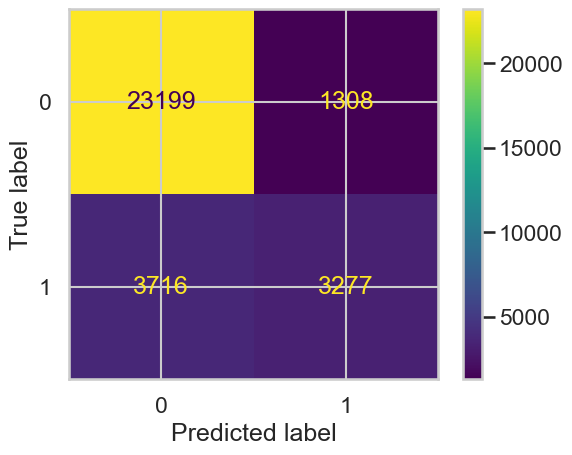

In [125]:
show_metrics(y_train, train_preds, train_probas)

Accuracy: 0.83
Precision: 0.68
Recall: 0.45
F1 score: 0.54
ROC AUC score (predict): 0.69
ROC AUC score (predict_proba): 0.85


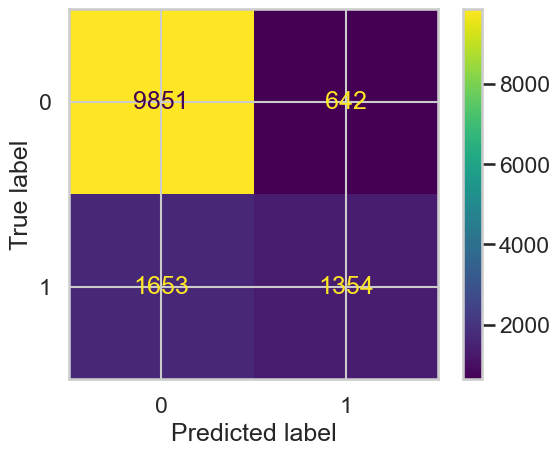

In [126]:
show_metrics(y_test, test_preds, test_probas)

entropy показал результат хуже gini

## Сравнение с sklearn

In [127]:
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [128]:
dt = DecisionTreeClassifier(criterion='gini', max_leaf_nodes=10, min_samples_leaf=20)
dt.fit(X_train_enc, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, min_samples_leaf=20)

In [129]:
train_preds = dt.predict(X_train_enc)
test_preds = dt.predict(X_test_enc)

In [130]:
train_probas = dt.predict_proba(X_train_enc)[:, 1]
test_probas = dt.predict_proba(X_test_enc)[:, 1]

Accuracy: 0.91
Precision: 0.85
Recall: 0.73
F1 score: 0.78
ROC AUC score (predict): 0.84
ROC AUC score (predict_proba): 0.95


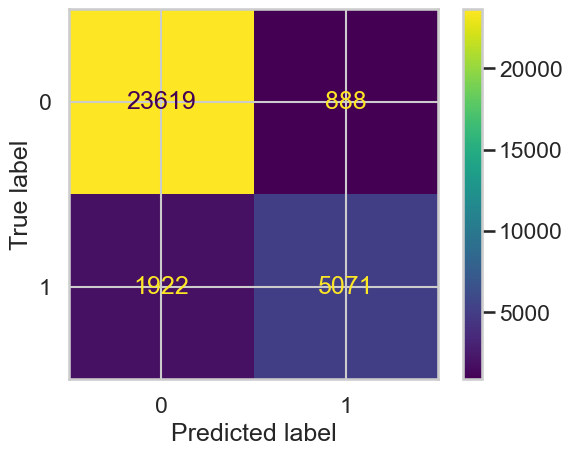

In [131]:
show_metrics(y_train, train_preds, train_probas)

Accuracy: 0.91
Precision: 0.83
Recall: 0.72
F1 score: 0.78
ROC AUC score (predict): 0.84
ROC AUC score (predict_proba): 0.95


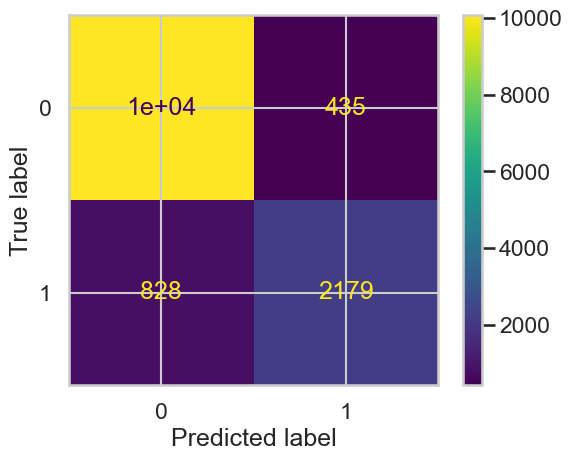

In [132]:
show_metrics(y_test, test_preds, test_probas)

Дерево из sklearn показало результат немного лучше самоделанного дерева